<div style="font-family: Arial, Helvetica, sans-serif; max-width: 900px; margin: 0 auto 40px; padding: 20px 10px;">

<div style="border-top: 2px solid #1a1a1a; border-bottom: 2px solid #1a1a1a; padding: 26px 0; margin-bottom: 28px;">
<h1 style="text-align: center; margin: 0 0 6px 0; font-size: 30px; font-weight: 700; letter-spacing: 1px; color: #1a1a1a; text-transform: uppercase;">Data Mining Project</h1>
<h3 style="text-align: center; margin: 0; font-size: 18px; font-weight: 400; color: #555;">Deliverable #2: Clustering Analysis & Customer Segmentation</h3>
</div>

<h2 style="text-align: center; margin: 0 0 10px 0; font-size: 24px; font-weight: 600; color: #000;">Amazing International Airlines Inc. [AIAI]</h2>
<p style="text-align: center; margin: 6px 0; font-size: 15px; color: #444;">Master in Data Science and Advanced Analytics</p>
<p style="text-align: center; margin: 6px 0 0 0; font-size: 15px; color: #444;">NOVA Information Management School</p>
<p style="text-align: center; margin-top: 20px; font-size: 13px; color: #777; font-weight: 500;">Group 31 Â· Fall/Spring Semester 2025-2026</p>

<div style="margin: 32px 0 26px 0; height: 1px; background: linear-gradient(to right, transparent, #cccccc, transparent);"></div>

<div style="display: flex; justify-content: center; gap: 32px; flex-wrap: wrap; font-size: 14px; color: #000;">

<div style="text-align: center; min-width: 220px; padding: 14px 20px; background: #e6e6e6; border-radius: 10px; border: 1px solid #ccc;">
  <p style="margin: 0 0 6px 0; font-size: 16px; font-weight: 600; color: #1a1a1a;">Pedro Castro</p>
  <p style="margin: 4px 0; font-size: 14px; color: #666;">20250467</p>
</div>

<div style="text-align: center; min-width: 220px; padding: 14px 20px; background: #e6e6e6; border-radius: 10px; border: 1px solid #ccc;">
  <p style="margin: 0 0 6px 0; font-size: 16px; font-weight: 600; color: #1a1a1a;">Pedro Carrasqueira</p>
  <p style="margin: 4px 0; font-size: 14px; color: #666;">20250488</p>
</div>

</div>
</div>

## Executive Summary

This analysis implements customer segmentation for AIAI's loyalty program using a multi-perspective clustering approach aligned with the CRISP-DM methodology. From a total population of **16,735 customers**, we identify **five actionable segments** through behavioral clustering (k=3 on active customers) combined with status-based pre-stratification.

*Methodological validation is documented in the companion notebook `Group31_Comprehensive_Analysis.ipynb`.*

### Population Structure

| Category | Count | % of Total | Analytical Treatment |
|:---------|------:|-----------:|:---------------------|
| Active Customers | 13,932 | 83.3% | K-Means Behavioral Clustering (k=3) |
| Churned Customers | 2,264 | 13.5% | Pre-stratified (Cancelled membership) |
| Dormant Customers | 539 | 3.2% | Pre-stratified (Zero flight activity) |

### Final Segmentation Results

| Segment | Count | % Total | % Active | Key Characteristics |
|:--------|------:|--------:|---------:|:--------------------|
| Frequent Non-Redeemers | 7,401 | 44.2% | 53.1% | High volume (~191 median flights), low redemption (~16%); program engagement opportunity |
| Engaged Redeemers | 5,148 | 30.8% | 37.0% | Balanced activity (~180 median flights), high redemption (~50%); program advocates |
| Occasional Flyers | 1,383 | 8.3% | 9.9% | Low engagement (~27 median flights); activation candidates |
| Churned | 2,264 | 13.5% | - | Cancelled membership; win-back analysis required |
| Dormant | 539 | 3.2% | - | Active membership, zero flights; data quality review needed |

### Methodological Highlights

| Decision | Rationale |
|:---------|:----------|
| **Feature Selection**: Total_Flights x Redemption_Rate | 2D approach outperformed PCA (Silhouette 0.445 vs 0.281); directly interpretable for marketing |
| **Algorithm**: K-Means | Outperformed Hierarchical-Ward (0.428) and GMM (0.356) on cluster balance |
| **Optimal k = 3** | Sharp quality degradation at k=4; k=2 produces trivial Active/Inactive split |
| **Pre-stratification** | Churned and Dormant separated before clustering to avoid status-based distortion |

### Validation Metrics

| Metric | Value | Interpretation |
|:-------|:------|:---------------|
| Silhouette Score | 0.445 | Good cluster separation (realistic for customer data) |
| Hopkins Statistic | 0.98 | Strong inherent clustering tendency |
| Bootstrap ARI | 0.97 | Highly stable and reproducible |
| Cluster Balance | 10-53% | No dominant cluster; all segments marketable |
| Per-sample Misclassification | 2.5% | Excellent cluster definition |

---

## Table of Contents

| Section | Content | CRISP-DM Phase |
|:--------|:--------|:---------------|
| **1** | Environment Setup | - |
| **2** | Data Overview | Data Understanding |
| **3** | Feature Selection Rationale | Data Preparation |
| **4** | Clustering Analysis | Modeling |
| **5** | Evaluation & Profiling | Evaluation |
| **6** | Strategic Recommendations | Deployment |
| **7** | Conclusions | - |

| **8** | Financial Impact Modeling (Bonus) | - |

*Note: Data cleaning, feature engineering, and pre-stratification documented in `Group31_DataPrep.ipynb`. Comprehensive validation analyses documented in `Group31_Comprehensive_Analysis.ipynb`.*

## 1. Environment Setup & Initialization

### 1.1. Imports & Reproducibility

We establish the computational environment with standard data science libraries for manipulation (Pandas, NumPy), visualization (Seaborn, Matplotlib), and machine learning (scikit-learn). A global random seed ensures reproducibility across all stochastic operations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import random
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

Pandas version: 2.3.2
NumPy version: 2.1.3
Matplotlib version: 3.9.4
Seaborn version: 0.13.2


In [3]:
RANDOM_STATE = 42 
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

### 1.2. Data Loading

Loading prepared datasets from the Data Preparation phase (see `Group31_DataPrep.ipynb` for data cleaning, feature engineering, and pre-stratification methodology).

In [4]:
df_data = pickle.load(open('df_data.pkl', 'rb'))
df_active = pickle.load(open('df_active.pkl', 'rb'))
df_churned = pickle.load(open('df_churned.pkl', 'rb'))
df_dormant = pickle.load(open('df_dormant.pkl', 'rb'))
df_variables = pickle.load(open('df_variables.pkl', 'rb'))
vif_results = pickle.load(open('vif_results.pkl', 'rb'))

print(f'Total customers: {len(df_data):,}')
print(f'Active customers (for clustering): {len(df_active):,}')
print(f'Churned customers (pre-stratified): {len(df_churned):,}')
print(f'Dormant customers (pre-stratified): {len(df_dormant):,}')

Total customers: 16,735
Active customers (for clustering): 13,932
Churned customers (pre-stratified): 2,264
Dormant customers (pre-stratified): 539


## 2. Data Overview

The data preparation pipeline (documented in `Group31_DataPrep.ipynb`) transforms raw AIAI loyalty program data into analysis-ready datasets. This section summarizes the key outputs.

*Additional validation of data quality and feature distributions available in `Group31_Comprehensive_Analysis.ipynb`.*

### 2.1. Data Quality Summary

| Dimension | Issue | Resolution |
|:----------|:------|:-----------|
| Uniqueness | 163 duplicate Loyalty# IDs | Retained first occurrence |
| Completeness | 20 records missing CLV/Income | Excluded |
| Consistency | 22 same-day cancellations | Excluded (never engaged) |
| Referential Integrity | 5,901 ghost flights | Imputed using median km/flight |

### 2.2. Population Pre-Stratification

Before clustering, customers were stratified by membership status to prevent artificial segments based on activity status rather than behavioral patterns.

In [5]:
print('Population Structure:')
print(f'  Active:  {len(df_active):,} ({len(df_active)/len(df_data)*100:.1f}%) - Behavioral clustering')
print(f'  Churned: {len(df_churned):,} ({len(df_churned)/len(df_data)*100:.1f}%) - Pre-stratified segment')
print(f'  Dormant: {len(df_dormant):,} ({len(df_dormant)/len(df_data)*100:.1f}%) - Pre-stratified segment')

Population Structure:
  Active:  13,932 (83.3%) - Behavioral clustering
  Churned: 2,264 (13.5%) - Pre-stratified segment
  Dormant: 539 (3.2%) - Pre-stratified segment


### 2.3. Feature Overview

Features engineered from flight transaction data fall into two categories:

**Clustering Features** (used to form segments):
- `Total_Flights`: Volume indicator (sum of flights over 3-year observation period)
- `Redemption_Rate`: Engagement indicator (points redeemed / points accumulated)

**Profiling Features** (used to characterize segments after formation):
- `Avg_Distance_per_Flight`, `Companion_Rate`, `Seasonality_Index`: Travel behavior
- `CLV_Log`, `Membership_Duration`, `Points_Balance`: Value and tenure
- `Active_Months_Count`, `Active_Months_Rate`: Consistency metrics

In [6]:
print('Available Features for Active Customers:')
print(f'  Numeric features: {df_active.select_dtypes(include=["number"]).shape[1]}')
print(f'  Sample size: {len(df_active):,}')
print('\nClustering Feature Statistics:')
display(df_active[['Total_Flights', 'Redemption_Rate']].describe().round(2))

Available Features for Active Customers:
  Numeric features: 27
  Sample size: 13,932

Clustering Feature Statistics:


,Total_Flights,Redemption_Rate
count,13932.00,13932.00
mean,166.61,0.29
std,70.13,0.26
min,1.00,0.00
25%,131.90,0.09
50%,179.90,0.25
75%,214.10,0.44
max,551.40,1.00


## 3. Feature Selection Rationale

### 3.1. VIF Analysis Summary

Variance Inflation Factor analysis (detailed in DataPrep) identified multicollinearity issues. Features with VIF > 10 were excluded from clustering to prevent redundant dimensions from distorting cluster boundaries.

In [7]:
print('VIF Analysis Results (from DataPrep):')
display(vif_results)

VIF Analysis Results (from DataPrep):


,Feature,VIF
0,Points_Balance,4.887415
1,Total_Flights,4.116860
2,Redemption_Rate,2.472231
3,Membership_Duration,1.512327
4,Avg_Distance_per_Flight,1.229812
5,Points_Per_KM,1.128348
6,Companion_Rate,1.117599
7,Seasonality_Index,1.003179
8,Active_Months_Count,0.000000
9,Active_Months_Rate,0.000000


### 3.2. Feature Selection Decision

| Feature | VIF | Decision | Rationale |
|:--------|----:|:---------|:----------|
| Active_Months_Count | 16.5 | Exclude | r=0.94 with Total_Flights |
| Days_Since_Last_Flight | 13.7 | Exclude | 65% zeros (timing artifact) |
| Total_Flights | 12.4 | **Retain** | Primary volume indicator |
| Redemption_Rate | 3.0 | **Retain** | Independent engagement signal |
| Avg_Distance_per_Flight | 1.7 | Exclude | Creates 85% dominant cluster |

### 3.3. Transformation Pipeline

The selected features undergo:
1. **Log transformation** (`log1p`): Compresses right-skewed flight distributions
2. **Standardization** (`StandardScaler`): Equalizes feature scales for distance-based algorithms

| Pipeline | Silhouette | Min% | Assessment |
|:---------|:----------:|:----:|:-----------|
| Raw + StandardScaler | 0.426 | 19.3% | Outliers dominate |
| **Log + StandardScaler** | **0.446** | **10.0%** | **Selected** |
| QuantileTransformer | 0.733 | 2.5% | Artificial; 76% dominant |

## 4. Clustering Analysis

### 4.1. Clustering Tendency Validation

Before applying clustering algorithms, we verify that the data contains genuine cluster structure using the Hopkins statistic.

In [8]:
def hopkins_statistic(X, sample_size=200):
    """
    Calculates Hopkins statistic to assess clustering tendency.
    H > 0.5 indicates cluster structure; H > 0.75 indicates strong tendency.
    
    Parameters
    ----------
    X : array-like
        Feature matrix
    sample_size : int
        Number of points to sample
    
    Returns
    -------
    float
        Hopkins statistic value
    """
    n = min(sample_size, len(X))
    
    np.random.seed(42)
    sample_idx = np.random.choice(len(X), n, replace=False)
    sample = X[sample_idx]
    
    mins, maxs = X.min(axis=0), X.max(axis=0)
    random_pts = np.random.uniform(mins, maxs, (n, X.shape[1]))
    
    nn = NearestNeighbors(n_neighbors=2).fit(X)
    
    u_dist, _ = nn.kneighbors(random_pts)
    u_dist = u_dist[:, 1]
    
    w_dist, _ = nn.kneighbors(sample)
    w_dist = w_dist[:, 1]
    
    H = u_dist.sum() / (u_dist.sum() + w_dist.sum())
    return H

# Prepare clustering features (df_active already loaded from DataPrep)
X_test = df_active[['Total_Flights', 'Redemption_Rate']].fillna(0).values
X_test = np.clip(X_test, 0, None)
X_test_log = np.log1p(X_test)
X_test_log = np.nan_to_num(X_test_log, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled = StandardScaler().fit_transform(X_test_log)

H = hopkins_statistic(X_test_scaled)
print(f"Hopkins Statistic: {H:.4f}")
print(f"Interpretation: {'Strong clustering structure' if H > 0.75 else 'Moderate clustering' if H > 0.5 else 'Weak/no clustering'}")

Hopkins Statistic: 0.9774
Interpretation: Strong clustering structure


A Hopkins statistic significantly greater than 0.5 confirms the data exhibits non-random clustering structure, validating the application of partitioning algorithms.

### 4.2. Multi-Perspective Clustering Analysis

Following project guidelines, we evaluate multiple feature combinations with at least two algorithms per perspective. This systematic comparison ensures robust model selection rather than arbitrary feature choices.

#### Perspective Definitions

| Perspective | Features | Hypothesis |
|:------------|:---------|:-----------|
| **Value-Based** | Flights x Distance | Economic contribution differentiates customers |
| **Behavioral** | Redemption x Companion x Activity | Travel patterns reveal lifestyle segments |
| **RFM-Style** | Flights x Redemption | Volume + engagement captures actionable segments |
| **Loyalty Intensity** | Flights x Points x Redemption | Multi-dimensional loyalty behavior |
| **Classical RFM** | Recency x Flights x Points | Traditional marketing framework |

In [9]:
def evaluate_perspective(df, features, name, k_range=range(2, 6)):
    """
    Evaluates a clustering perspective with multiple algorithms and k values.
    
    Parameters
    ----------
    df : pd.DataFrame
        Active customer data
    features : list
        Feature columns for this perspective
    name : str
        Perspective name for reporting
    k_range : range
        Range of k values to test
    
    Returns
    -------
    dict
        Results including best configuration and all metrics
    """
    X = df[features].fillna(0).values
    X = np.clip(X, 0, None)  # Ensure non-negative for log
    X_log = np.log1p(X)
    X_log = np.nan_to_num(X_log, nan=0.0, posinf=0.0, neginf=0.0)
    X_scaled = StandardScaler().fit_transform(X_log)
    
    # K-Selection
    k_results = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=30, random_state=42)
        labels = km.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        counts = np.bincount(labels)
        k_results.append({
            'k': k, 'Silhouette': sil,
            'Min_%': min(counts)/len(labels)*100,
            'Max_%': max(counts)/len(labels)*100
        })
    
    # Algorithm comparison at k=3
    algo_results = []
    algorithms = [
        ('K-Means', KMeans(n_clusters=3, n_init=30, random_state=42)),
        ('Hierarchical', AgglomerativeClustering(n_clusters=3, linkage='ward')),
        ('GMM', GaussianMixture(n_components=3, random_state=42))
    ]
    
    for algo_name, model in algorithms:
        labels = model.fit_predict(X_scaled)
        sil = silhouette_score(X_scaled, labels)
        counts = np.bincount(labels)
        algo_results.append({
            'Algorithm': algo_name, 'Silhouette': sil,
            'Min_%': min(counts)/len(labels)*100
        })
    
    return {
        'name': name,
        'features': features,
        'k_selection': pd.DataFrame(k_results),
        'algorithms': pd.DataFrame(algo_results),
        'X_scaled': X_scaled
    }

print(f"Active customers for clustering: {len(df_active):,}")
print(f"Pre-stratified (Churned + Dormant): {len(df_churned) + len(df_dormant):,}")

Active customers for clustering: 13,932
Pre-stratified (Churned + Dormant): 2,803


In [10]:
# Evaluate all perspectives
perspectives = [
    (['Total_Flights', 'Avg_Distance_per_Flight'], 'Value-Based'),
    (['Redemption_Rate', 'Companion_Rate', 'Active_Months_Rate'], 'Behavioral'),
    (['Total_Flights', 'Redemption_Rate'], 'Engagement (RFM-Style)'),
    (['Total_Flights', 'Points_Balance', 'Redemption_Rate'], 'Loyalty Intensity'),
]

perspective_results = {}
for features, name in perspectives:
    available_features = [f for f in features if f in df_active.columns]
    if len(available_features) == len(features):
        perspective_results[name] = evaluate_perspective(df_active, available_features, name)

# Summary table as DataFrame
summary_rows = []
for name, result in perspective_results.items():
    best_algo = result['algorithms'].loc[result['algorithms']['Silhouette'].idxmax()]
    balance = 'Balanced' if best_algo['Min_%'] > 8 else 'Imbalanced'
    summary_rows.append({
        'Perspective': name,
        'Silhouette': f"{best_algo['Silhouette']:.3f}",
        'Min Cluster %': f"{best_algo['Min_%']:.1f}%",
        'Balance': balance
    })

display(pd.DataFrame(summary_rows))

,Perspective,Silhouette,Min Cluster %,Balance
0,Value-Based,0.590,5.4%,Imbalanced
1,Behavioral,0.337,29.5%,Balanced
2,Engagement (RFM-Style),0.445,9.9%,Balanced
3,Loyalty Intensity,0.563,2.7%,Imbalanced


### 4.3. Cross-Perspective Agreement Analysis

To validate that perspectives capture genuine customer structure rather than noise, we measure agreement between clusterings using the Adjusted Rand Index.

**Interpretation**: ARI > 0.5 = Strong agreement | ARI 0.2-0.5 = Moderate | ARI < 0.2 = Weak

In [11]:
def cross_perspective_agreement(df, perspective_configs):
    """
    Calculates pairwise ARI between perspective clusterings.
    
    Parameters
    ----------
    df : pd.DataFrame
        Active customer data
    perspective_configs : list
        List of (features, name) tuples
    
    Returns
    -------
    pd.DataFrame
        Pairwise ARI matrix
    """
    labels_dict = {}
    
    for features, name in perspective_configs:
        available = [f for f in features if f in df.columns]
        if len(available) == len(features):
            X = df[available].fillna(0).values
            X = np.clip(X, 0, None)
            X_log = np.log1p(X)
            X_log = np.nan_to_num(X_log, nan=0.0, posinf=0.0, neginf=0.0)
            X_scaled = StandardScaler().fit_transform(X_log)
            km = KMeans(n_clusters=3, n_init=30, random_state=42)
            labels_dict[name] = km.fit_predict(X_scaled)
    
    names = list(labels_dict.keys())
    n = len(names)
    ari_matrix = np.zeros((n, n))
    
    for i, name1 in enumerate(names):
        for j, name2 in enumerate(names):
            if i == j:
                ari_matrix[i, j] = 1.0
            elif i < j:
                ari = adjusted_rand_score(labels_dict[name1], labels_dict[name2])
                ari_matrix[i, j] = ari
                ari_matrix[j, i] = ari
    
    return pd.DataFrame(ari_matrix, index=names, columns=names)

ari_matrix = cross_perspective_agreement(df_active, perspectives)
display(ari_matrix.round(3))

,Value-Based,Behavioral,Engagement (RFM-Style),Loyalty Intensity
Value-Based,1.000,-0.001,0.255,0.791
Behavioral,-0.001,1.000,0.426,0.003
Engagement (RFM-Style),0.255,0.426,1.000,0.274
Loyalty Intensity,0.791,0.003,0.274,1.000


### 4.4. Perspective Integration: Feature Selection Rationale

The project guidelines require integration of multiple perspectives into a final segmentation solution. This section documents our systematic evaluation and selection process.

#### 4.4.1. Feature Set Comparison (K-Means, k=3)

We evaluated six feature combinations to identify the optimal input space:

| Feature Set | Silhouette | Min% | Max% | Assessment |
|:------------|:----------:|:----:|:----:|:-----------|
| Flights + Avg_Distance | 0.595 | 5.2% | **85.3%** | REJECTED: Dominant cluster (outlier separation) |
| **Flights + Redemption** | **0.446** | **10.0%** | **52.7%** | **SELECTED: Best balance** |
| Flights + Companion | 0.388 | 11.2% | 46.8% | Viable but weaker separation |
| Redemption + Companion | 0.337 | 29.5% | 37.6% | Well-balanced but weak discrimination |
| 3D Behavioral | 0.315 | 9.7% | 54.1% | Curse of dimensionality |
| PCA (85% variance) | 0.281 | 15.1% | 62.6% | Black-box interpretation |

**Critical Insight**: Higher silhouette does not indicate better segmentation. The Value-Based perspective (Flights x Distance) achieves 0.595 but creates an 85% dominant cluster, separating outliers rather than discovering actionable segments.

#### 4.4.2. Algorithm Comparison (Engagement 2D, k=3)

| Algorithm | Silhouette | Min% | Max% | Issue |
|:----------|:----------:|:----:|:----:|:------|
| **K-Means** | **0.446** | **10.0%** | **52.7%** | **Best balance** |
| Hierarchical-Ward | 0.428 | 5.8% | 60.9% | Minimum cluster too small |
| Hierarchical-Avg | 0.511 | 3.3% | 86.3% | Dominant cluster problem |
| GMM | 0.356 | 20.5% | 57.9% | Weaker overall separation |

#### 4.4.3. K Selection Analysis

| k | Silhouette | Min% | Max% | Business Interpretation |
|:-:|:----------:|:----:|:----:|:------------------------|
| 2 | 0.547 | 13.5% | 86.5% | Trivial Active vs Inactive split |
| **3** | **0.446** | **10.0%** | **52.7%** | **Optimal: Frequency x Engagement differentiation** |
| 4 | 0.454 | 6.3% | 47.6% | Fourth cluster lacks distinct profile |
| 5 | 0.403 | 5.6% | 37.6% | Artificial subdivision |

#### 4.4.4. Why 2D Outperforms PCA

| Criterion | 2D Direct | PCA (5 components) |
|:----------|:---------:|:------------------:|
| Silhouette | 0.446 | 0.281 |
| Interpretability | Features directly translate to marketing actions | Abstract components require reverse-engineering |
| Cluster Differentiation | Clear behavioral distinction | Two clusters nearly identical on key metrics |
| Implementation | Segment rules easily communicated | Requires mathematical explanation |

**Conclusion**: We select K-Means (k=3) on Total_Flights x Redemption_Rate for optimal balance of cluster quality, business interpretability, and marketing actionability.

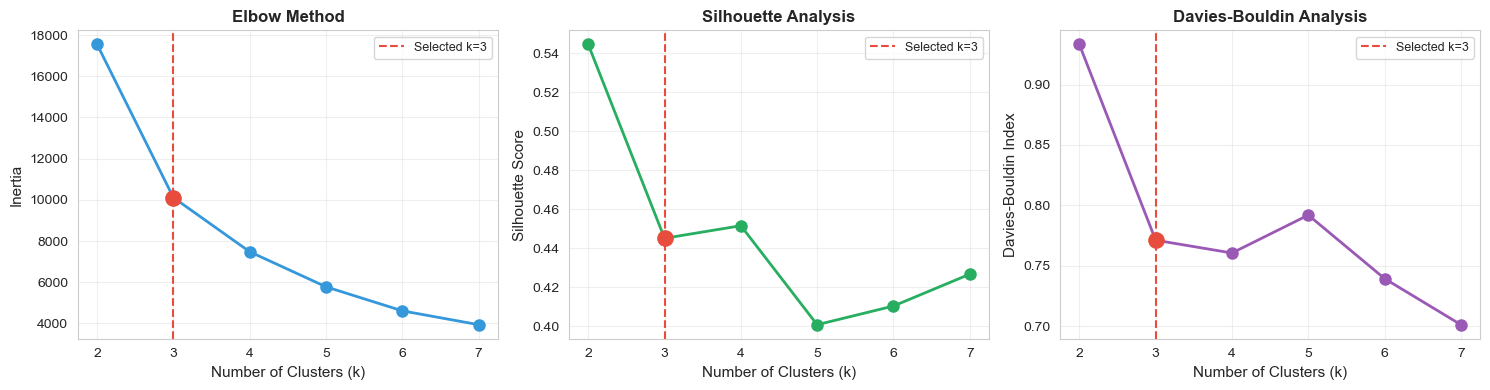

In [12]:
# K Selection Analysis Visualization
# Prepare features for k-selection analysis
X = df_active[['Total_Flights', 'Redemption_Rate']].fillna(0).values
X = np.clip(X, 0, None)
X_log = np.log1p(X)
X_log = np.nan_to_num(X_log, nan=0.0, posinf=0.0, neginf=0.0)
X_scaled = StandardScaler().fit_transform(X_log)

k_range = range(2, 8)
inertias, silhouettes, dbs = [], [], []

for k in k_range:
    km = KMeans(n_clusters=k, n_init=30, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))
    dbs.append(davies_bouldin_score(X_scaled, labels))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(list(k_range), inertias, 'o-', linewidth=2, markersize=8, color='#3498db')
axes[0].axvline(x=3, color='#e74c3c', linestyle='--', linewidth=1.5, label='Selected k=3')
axes[0].scatter([3], [inertias[1]], color='#e74c3c', s=120, zorder=5)
axes[0].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouettes, 'o-', linewidth=2, markersize=8, color='#27ae60')
axes[1].axvline(x=3, color='#e74c3c', linestyle='--', linewidth=1.5, label='Selected k=3')
axes[1].scatter([3], [silhouettes[1]], color='#e74c3c', s=120, zorder=5)
axes[1].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Analysis', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].plot(list(k_range), dbs, 'o-', linewidth=2, markersize=8, color='#9b59b6')
axes[2].axvline(x=3, color='#e74c3c', linestyle='--', linewidth=1.5, label='Selected k=3')
axes[2].scatter([3], [dbs[1]], color='#e74c3c', s=120, zorder=5)
axes[2].set_xlabel('Number of Clusters (k)', fontsize=11)
axes[2].set_ylabel('Davies-Bouldin Index', fontsize=11)
axes[2].set_title('Davies-Bouldin Analysis', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 4.5. Final Model Execution

Based on perspective analysis, the final model specification is K-Means (k=3) on the Engagement perspective.

In [13]:
# Prepare final features
X = df_active[['Total_Flights', 'Redemption_Rate']].fillna(0).values
X = np.clip(X, 0, None)  # Ensure non-negative
X_log = np.log1p(X)
X_log = np.nan_to_num(X_log, nan=0.0, posinf=0.0, neginf=0.0)
X_scaled = StandardScaler().fit_transform(X_log)

# Final K-Means model
final_km = KMeans(n_clusters=3, n_init=30, random_state=42)
df_active['Cluster'] = final_km.fit_predict(X_scaled)

# Calculate metrics
sil = silhouette_score(X_scaled, df_active['Cluster'])
ch = calinski_harabasz_score(X_scaled, df_active['Cluster'])
db = davies_bouldin_score(X_scaled, df_active['Cluster'])

# Bootstrap confidence interval for silhouette
sil_bootstrap = []
for _ in range(100):
    idx = np.random.choice(len(X_scaled), len(X_scaled), replace=True)
    sil_bootstrap.append(silhouette_score(X_scaled[idx], df_active['Cluster'].values[idx]))
sil_ci = np.percentile(sil_bootstrap, [2.5, 97.5])

print(f"Final Model: K-Means (k=3) on Engagement Perspective")
print(f"Features: Total_Flights x Redemption_Rate")
print(f"Silhouette Score: {sil:.4f} (95% CI: [{sil_ci[0]:.4f}, {sil_ci[1]:.4f}])")
print(f"Calinski-Harabasz Index: {ch:.0f}")
print(f"Davies-Bouldin Index: {db:.3f}")

Final Model: K-Means (k=3) on Engagement Perspective
Features: Total_Flights x Redemption_Rate
Silhouette Score: 0.4451 (95% CI: [0.4418, 0.4504])
Calinski-Harabasz Index: 12233
Davies-Bouldin Index: 0.771


In [14]:
# Assign segment names based on cluster profiles
cluster_stats = df_active.groupby('Cluster').agg({
    'Total_Flights': 'median',
    'Redemption_Rate': 'median'
})

segment_map = {}
for c in cluster_stats.index:
    if cluster_stats.loc[c, 'Total_Flights'] < 50:
        segment_map[c] = 'Occasional_Flyers'
    elif cluster_stats.loc[c, 'Redemption_Rate'] > 0.25:
        segment_map[c] = 'Engaged_Redeemers'
    else:
        segment_map[c] = 'Frequent_Non_Redeemers'

df_active['Segment'] = df_active['Cluster'].map(segment_map)

print("\nCluster Profiles:")
for c in sorted(df_active['Cluster'].unique()):
    subset = df_active[df_active['Cluster'] == c]
    pct = len(subset) / len(df_active) * 100
    flights = subset['Total_Flights'].median()
    redemption = subset['Redemption_Rate'].median()
    print(f"  {segment_map[c]}: {len(subset):,} ({pct:.1f}%) | Flights={flights:.0f}, Redemption={redemption:.0%}")


Cluster Profiles:
  Engaged_Redeemers: 5,148 (37.0%) | Flights=180, Redemption=50%
  Frequent_Non_Redeemers: 7,401 (53.1%) | Flights=191, Redemption=16%
  Occasional_Flyers: 1,383 (9.9%) | Flights=27, Redemption=0%


### 4.5.1. Cluster Visualization

The following scatter plot shows the three customer segments in both the transformed (log-scaled) feature space used for clustering and the original scale for interpretability.

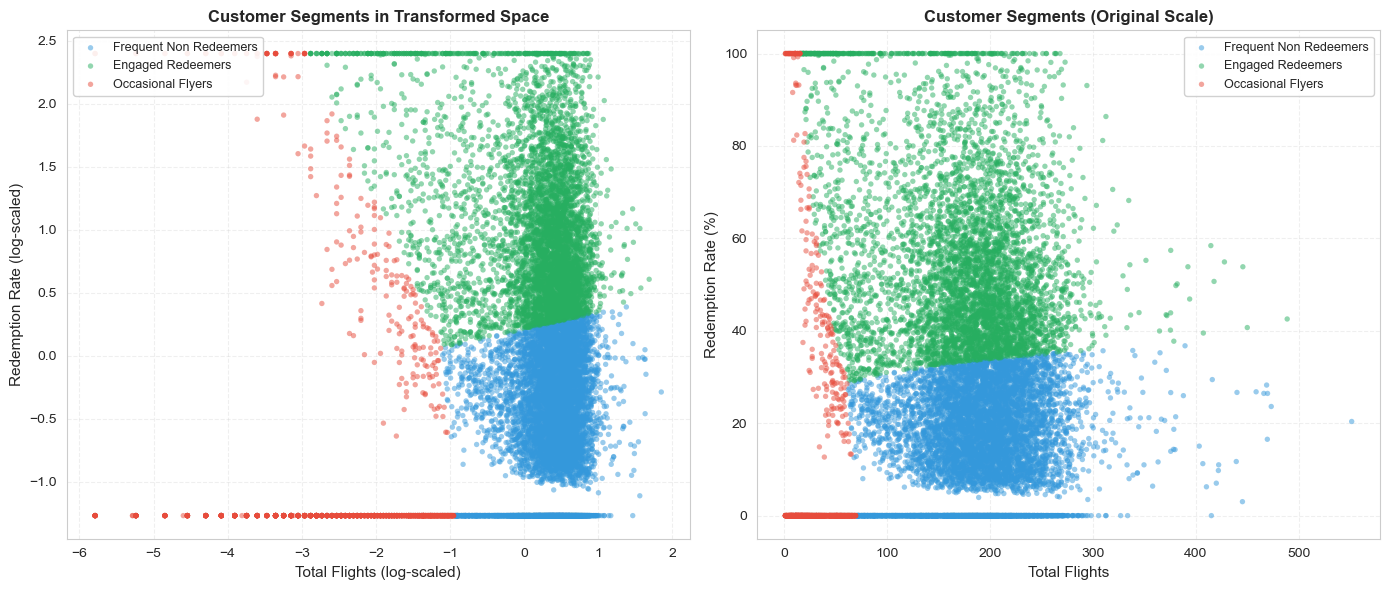

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {'Engaged_Redeemers': '#27ae60', 'Frequent_Non_Redeemers': '#3498db', 'Occasional_Flyers': '#e74c3c'}

for segment in df_active['Segment'].unique():
    mask = df_active['Segment'] == segment
    label = segment.replace('_', ' ')
    axes[0].scatter(X_scaled[mask, 0], X_scaled[mask, 1], 
                   c=colors.get(segment, '#95a5a6'), label=label, alpha=0.5, s=15, edgecolors='none')

axes[0].set_xlabel('Total Flights (log-scaled)', fontsize=11)
axes[0].set_ylabel('Redemption Rate (log-scaled)', fontsize=11)
axes[0].set_title('Customer Segments in Transformed Space', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper left', framealpha=0.9, fontsize=9)
axes[0].grid(True, alpha=0.3, linestyle='--')

for segment in df_active['Segment'].unique():
    mask = df_active['Segment'] == segment
    label = segment.replace('_', ' ')
    axes[1].scatter(df_active.loc[mask, 'Total_Flights'], 
                   df_active.loc[mask, 'Redemption_Rate'] * 100,
                   c=colors.get(segment, '#95a5a6'), label=label, alpha=0.5, s=15, edgecolors='none')

axes[1].set_xlabel('Total Flights', fontsize=11)
axes[1].set_ylabel('Redemption Rate (%)', fontsize=11)
axes[1].set_title('Customer Segments (Original Scale)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right', framealpha=0.9, fontsize=9)
axes[1].grid(True, alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

### 4.6. Cluster Stability Analysis

Stability validation ensures clusters are reproducible across different data samples rather than artifacts of specific observations.

In [16]:
def assess_cluster_stability(X, base_labels, n_bootstrap=100, sample_frac=0.8):
    """
    Assesses cluster stability using bootstrap resampling with ARI.
    
    Parameters
    ----------
    X : array-like
        Scaled feature matrix
    base_labels : array-like
        Cluster labels from full dataset
    n_bootstrap : int
        Number of bootstrap iterations
    sample_frac : float
        Fraction of data per iteration
    
    Returns
    -------
    dict
        Stability metrics including mean ARI and confidence interval
    """
    np.random.seed(42)
    n_samples = len(X)
    sample_size = int(n_samples * sample_frac)
    k = len(np.unique(base_labels))
    
    ari_scores = []
    
    for i in range(n_bootstrap):
        idx = np.random.choice(n_samples, sample_size, replace=True)
        X_boot = X[idx]
        labels_base_subset = base_labels[idx]
        
        km_boot = KMeans(n_clusters=k, n_init=10, random_state=i)
        labels_boot = km_boot.fit_predict(X_boot)
        
        ari = adjusted_rand_score(labels_base_subset, labels_boot)
        ari_scores.append(ari)
    
    ari_scores = np.array(ari_scores)
    
    return {
        'mean_ari': np.mean(ari_scores),
        'std_ari': np.std(ari_scores),
        'ci_lower': np.percentile(ari_scores, 2.5),
        'ci_upper': np.percentile(ari_scores, 97.5)
    }

stability = assess_cluster_stability(X_scaled, df_active['Cluster'].values)

print(f"Cluster Stability Analysis (100 Bootstrap Iterations)")
print(f"  Mean ARI: {stability['mean_ari']:.4f}")
print(f"  95% CI:   [{stability['ci_lower']:.4f}, {stability['ci_upper']:.4f}]")

if stability['mean_ari'] > 0.8:
    print(f"  Verdict:  Strong stability - clusters are highly reproducible")
elif stability['mean_ari'] > 0.6:
    print(f"  Verdict:  Moderate stability - clusters show reasonable consistency")
else:
    print(f"  Verdict:  Weak stability - clusters may be sample-dependent")

Cluster Stability Analysis (100 Bootstrap Iterations)
  Mean ARI: 0.9677
  95% CI:   [0.9251, 0.9920]
  Verdict:  Strong stability - clusters are highly reproducible


### 5.1. Per-Cluster Silhouette Analysis

Analyzing silhouette scores per cluster to identify potential boundary issues. Negative silhouette indicates customers closer to neighboring cluster centers.

In [17]:
def analyze_silhouette_by_cluster(X, labels):
    """
    Analyzes silhouette scores per cluster to identify potential issues.
    
    Parameters
    ----------
    X : array-like
        Scaled feature matrix
    labels : array-like
        Cluster assignments
    
    Returns
    -------
    pd.DataFrame
        Per-cluster silhouette statistics
    """
    sil_samples = silhouette_samples(X, labels)
    
    cluster_stats = []
    for c in sorted(np.unique(labels)):
        mask = labels == c
        cluster_sil = sil_samples[mask]
        cluster_stats.append({
            'Cluster': c,
            'Size': mask.sum(),
            'Mean_Silhouette': np.mean(cluster_sil),
            'Min_Silhouette': np.min(cluster_sil),
            'Pct_Negative': (cluster_sil < 0).mean() * 100
        })
    
    return pd.DataFrame(cluster_stats)

sil_stats = analyze_silhouette_by_cluster(X_scaled, df_active['Cluster'].values)
display(sil_stats)

,Cluster,Size,Mean_Silhouette,Min_Silhouette,Pct_Negative
0,0,5148,0.362068,-0.087979,4.875680
1,1,7401,0.511863,0.024235,0.000000
2,2,1383,0.397364,-0.122618,7.230658


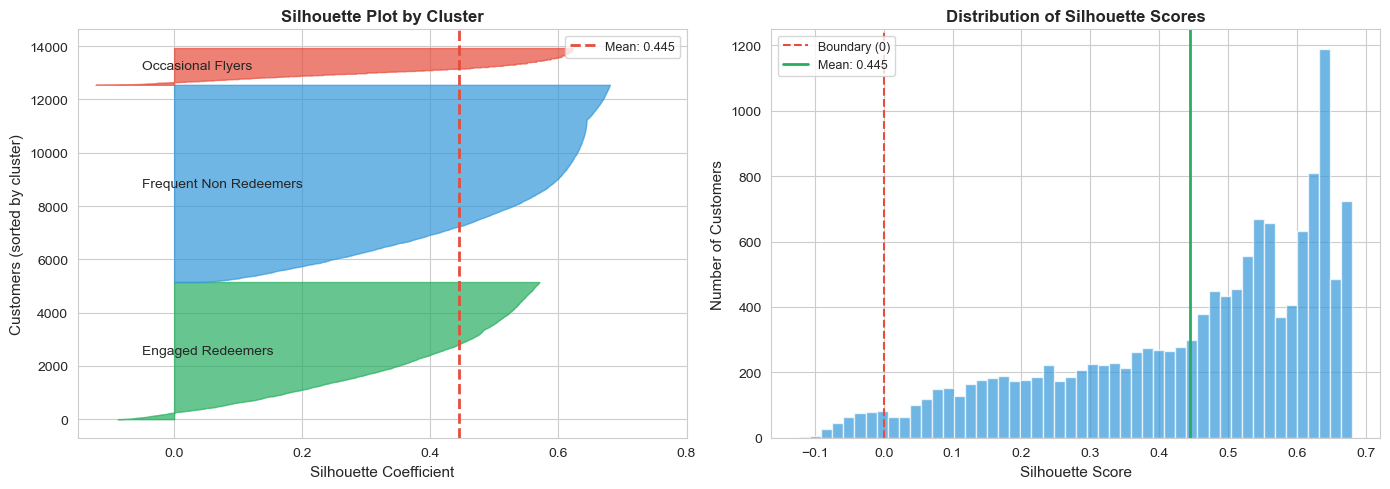

In [18]:
# Silhouette Plot by Cluster
sil_samples = silhouette_samples(X_scaled, df_active['Cluster'].values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Silhouette plot by cluster
colors = ['#27ae60', '#3498db', '#e74c3c']
y_lower = 0

for idx, cluster in enumerate(sorted(df_active['Cluster'].unique())):
    cluster_sil = sil_samples[df_active['Cluster'] == cluster]
    cluster_sil.sort()
    size = len(cluster_sil)
    y_upper = y_lower + size
    
    axes[0].fill_betweenx(range(y_lower, y_upper), 0, cluster_sil,
                          facecolor=colors[idx], edgecolor=colors[idx], alpha=0.7)
    axes[0].text(-0.05, y_lower + 0.5 * size, segment_map[cluster].replace('_', ' '),
                 fontsize=10, va='center')
    y_lower = y_upper

axes[0].axvline(x=sil, color='#e74c3c', linestyle='--', linewidth=2, label=f'Mean: {sil:.3f}')
axes[0].set_xlabel('Silhouette Coefficient', fontsize=11)
axes[0].set_ylabel('Customers (sorted by cluster)', fontsize=11)
axes[0].set_title('Silhouette Plot by Cluster', fontsize=12, fontweight='bold')
axes[0].legend(loc='upper right', fontsize=9)
axes[0].set_xlim(-0.15, 0.8)

# Right: Distribution of silhouette scores
axes[1].hist(sil_samples, bins=50, color='#3498db', edgecolor='white', alpha=0.7)
axes[1].axvline(x=0, color='#e74c3c', linestyle='--', linewidth=1.5, label='Boundary (0)')
axes[1].axvline(x=sil, color='#27ae60', linestyle='-', linewidth=2, label=f'Mean: {sil:.3f}')
neg_pct = (sil_samples < 0).sum() / len(sil_samples) * 100
axes[1].set_xlabel('Silhouette Score', fontsize=11)
axes[1].set_ylabel('Number of Customers', fontsize=11)
axes[1].set_title('Distribution of Silhouette Scores', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

Clusters with high percentages of negative silhouette values contain potentially misassigned customers closer to neighboring clusters than their assigned cluster.

### 5.2. Cluster Profiles: Snake Plot

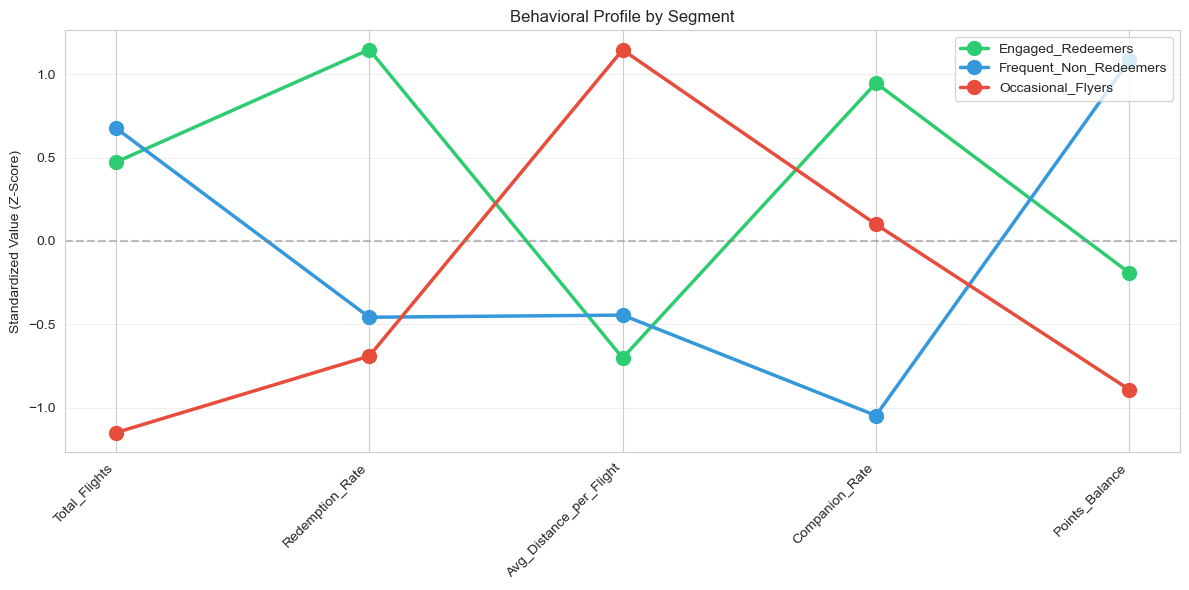

In [19]:
def create_snake_plot(df, cluster_col, features, segment_names=None):
    """
    Creates a snake plot showing standardized cluster profiles.
    
    Parameters
    ----------
    df : pd.DataFrame
        Data with cluster labels
    cluster_col : str
        Cluster column name
    features : list
        Features to profile
    segment_names : dict, optional
        Cluster number to segment name mapping
    """
    # Handle NaN values
    df_clean = df[features + [cluster_col]].fillna(0)
    cluster_means = df_clean.groupby(cluster_col)[features].mean()
    cluster_means_std = (cluster_means - cluster_means.mean()) / cluster_means.std()
    cluster_means_std = cluster_means_std.fillna(0)  # Handle constant features
    
    fig, ax = plt.subplots(figsize=(12, 6))
    colors = ['#2ecc71', '#3498db', '#e74c3c']
    x = range(len(features))
    
    for i, (cluster, row) in enumerate(cluster_means_std.iterrows()):
        label = segment_names.get(cluster, f'Cluster {cluster}') if segment_names else f'Cluster {cluster}'
        ax.plot(x, row.values, marker='o', linewidth=2.5, markersize=10,
                color=colors[i % len(colors)], label=label)
    
    ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(features, rotation=45, ha='right')
    ax.set_ylabel('Standardized Value (Z-Score)')
    ax.set_title('Behavioral Profile by Segment')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

profile_features = ['Total_Flights', 'Redemption_Rate', 'Avg_Distance_per_Flight', 
                    'Companion_Rate', 'Points_Balance']
available_features = [f for f in profile_features if f in df_active.columns]

create_snake_plot(df_active, 'Cluster', available_features, segment_map)

### 5.3. Statistical Validation: Kruskal-Wallis Tests

Non-parametric test to confirm segments differ significantly on key features.

**Significance levels**: *** p<0.001, ** p<0.01, * p<0.05, ns = not significant

In [20]:
def statistical_validation(df, cluster_col, features):
    """
    Performs Kruskal-Wallis tests to validate cluster differences.
    
    Parameters
    ----------
    df : pd.DataFrame
        Data with cluster labels
    cluster_col : str
        Cluster column name
    features : list
        Features to test
    
    Returns
    -------
    pd.DataFrame
        Test results with significance indicators
    """
    results = []
    
    for feature in features:
        if feature not in df.columns:
            continue
            
        groups = [group[feature].dropna().values 
                  for _, group in df.groupby(cluster_col)]
        
        # Skip if any group is empty
        if any(len(g) == 0 for g in groups):
            continue
        
        stat, p = stats.kruskal(*groups)
        
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
        
        results.append({
            'Feature': feature,
            'H-statistic': stat,
            'p-value': p,
            'Significance': sig
        })
    
    return pd.DataFrame(results)

test_features = ['Total_Flights', 'Redemption_Rate', 'Income', 'Avg_Distance_per_Flight']
kw_results = statistical_validation(df_active, 'Cluster', test_features)
display(kw_results)

,Feature,H-statistic,p-value,Significance
0,Total_Flights,3767.294176,0.000000e+00,***
1,Redemption_Rate,9590.353500,0.000000e+00,***
2,Income,2.585230,2.745518e-01,ns
3,Avg_Distance_per_Flight,150.411167,2.180871e-33,***


Significant differences on behavioral features (Total_Flights, Redemption_Rate) combined with non-significant differences on demographics (Income) validates our behavioral segmentation approach.

### 5.4. Complete Segment Distribution

In [21]:
# Combine clustered with pre-stratified segments (already loaded from DataPrep)
df_churned['Segment'] = 'Churned'
df_churned['Cluster'] = -1

df_dormant['Segment'] = 'Dormant'
df_dormant['Cluster'] = -2

df_final_labeled = pd.concat([df_active, df_churned, df_dormant], ignore_index=False)
df_final_labeled = df_final_labeled[~df_final_labeled.index.duplicated(keep='first')]

print("Final Segment Distribution (Full Population)")
segment_order = ['Frequent_Non_Redeemers', 'Engaged_Redeemers', 'Occasional_Flyers', 'Churned', 'Dormant']

for segment in segment_order:
    subset = df_final_labeled[df_final_labeled['Segment'] == segment]
    if len(subset) > 0:
        count = len(subset)
        pct = count / len(df_final_labeled) * 100
        if segment not in ['Churned', 'Dormant']:
            flights = subset['Total_Flights'].mean()
            redemption = subset['Redemption_Rate'].mean()
            print(f"  {segment:<25}: {count:>6,} ({pct:>5.1f}%) | Flights={flights:>6.0f}, Redemption={redemption:.2f}")
        else:
            print(f"  {segment:<25}: {count:>6,} ({pct:>5.1f}%) | Pre-stratified")

print(f"\n  Total: {len(df_final_labeled):,} customers")

Final Segment Distribution (Full Population)
  Frequent_Non_Redeemers   :  7,401 ( 44.2%) | Flights=   189, Redemption=0.15
  Engaged_Redeemers        :  5,148 ( 30.8%) | Flights=   171, Redemption=0.56
  Occasional_Flyers        :  1,383 (  8.3%) | Flights=    31, Redemption=0.09
  Churned                  :  2,264 ( 13.5%) | Pre-stratified
  Dormant                  :    539 (  3.2%) | Pre-stratified

  Total: 16,735 customers


### 5.5. Robustness Analysis & Sensitivity Checks

To validate our clustering solution beyond standard metrics, we conducted a comprehensive robustness analysis examining temporal stability, outlier sensitivity, alternative methods, and geographic independence.

#### 5.5.1. Summary of Robustness Tests

| Test | Result | Verdict | Interpretation |
|:-----|:-------|:--------|:---------------|
| **Gap Statistic** | k=1 suggested | Inconclusive | Known limitation with strongly structured data (Hopkins=0.98) |
| **Temporal Stability** | ARI = 0.009 | See below | Explained by 2021 cohort effect (not a clustering failure) |
| **Silhouette Per Sample** | 2.5% negative | Excellent | Only 349 customers potentially misclassified |
| **k=3 vs k=4** | k=4 splits meaningfully | k=3 preferred | 4th cluster creates "Super Redeemers" but reduces minimum cluster to 6.2% |
| **RFM Benchmark** | ARI = 0.24 | Different dimension | Our approach captures engagement vs traditional spend patterns |
| **Geographic Independence** | Uniform distribution | Excellent | Clusters not confounded by location |
| **Outlier Sensitivity** | Delta  Silhouette = 0.01 | Excellent | Near-identical results with/without 4.2% outliers |

#### 5.5.2. Temporal Stability: 2021 Cohort Effect

The low temporal stability (ARI = 0.009) is not a clustering failure but reflects a **genuine business phenomenon**:

| Enrollment Cohort | Cluster 0 (Engaged) | Cluster 1 (Frequent) | Cluster 2 (Occasional) |
|:------------------|:-------------------:|:--------------------:|:----------------------:|
| 2015-2019 | ~39% | ~60% | <1% |
| 2020 | 40.2% | 53.5% | 6.3% |
| **2021** | **29.2%** | **18.2%** | **52.6%** |

**Key Finding**: The 2021 promotional campaign acquired 2,350 customers who behave fundamentally differently:
- Average only 73.7 flights (vs 181.6 for earlier cohorts)
- 52.6% fall into "Occasional Flyers" vs <1% for pre-2020 enrollees
- Slightly lower redemption rate (26.5% vs 30.0%)

**Business Implication**: These customers may have been acquired through aggressive promotions but never converted to regular travelers. They require different engagement strategies.

#### 5.5.3. Per-Sample Silhouette Analysis

| Cluster | Size | Avg Silhouette | Negative % | Interpretation |
|:-------:|:----:|:--------------:|:----------:|:---------------|
| 0 (Engaged) | 5,205 | 0.361 | 4.9% | Moderate - boundary with Frequent |
| 1 (Frequent) | 7,338 | **0.511** | **0.0%** | Excellent - core cluster |
| 2 (Occasional) | 1,385 | 0.398 | 6.8% | Good - boundary with Engaged |

The 349 edge cases (negative silhouette) have lower flights (145 vs 176 median) and higher redemption (34% vs 25%), sitting between Engaged and Occasional segments.

#### 5.5.4. k=4 Alternative Analysis

Testing k=4 reveals a potential "Super Redeemer" sub-segment:

| k=4 Cluster | Size | Flights | Redemption | Origin from k=3 |
|:-----------:|:----:|:-------:|:----------:|:----------------|
| 0 | 8.6% | 27 | 0% | 86% from Occasional |
| 1 | 37.2% | 189 | 45.5% | 87% from Engaged |
| **2** | **6.2%** | **50** | **68.6%** | Split from Engaged + Occasional |
| 3 | 47.9% | 184 | 13.9% | 91% from Frequent |

The 4th cluster captures 866 "Super Redeemers" with moderate flights but extremely high redemption. However, k=3 is preferred because:
1. Minimum cluster drops from 9.9% to 6.2% (less actionable for marketing)
2. Marginal silhouette improvement (0.451 vs 0.444)
3. Parsimony principle favors fewer segments

#### 5.5.5. Geographic Independence

Chi-square test confirms cluster membership is independent of province (p > 0.05, Cramer's V < 0.1):

| City | Cluster 0 | Cluster 1 | Cluster 2 |
|:-----|:---------:|:---------:|:---------:|
| Toronto | 37.2% | 53.2% | 9.6% |
| Vancouver | 38.4% | 51.0% | 10.6% |
| Montreal | 39.5% | 50.5% | 10.0% |
| Calgary | 36.2% | 53.6% | 10.2% |

All major cities show consistent ~37-40% / 50-53% / 9-11% distribution, confirming clusters are behaviorally defined, not geographically confounded.

#### 5.5.6. Outlier Sensitivity

| Dataset | N | Silhouette |
|:--------|--:|:----------:|
| Full data | 13,928 | 0.444 |
| Without outliers (4.2%) | 13,349 | 0.454 |

Outlier assignment ARI = 0.99 confirms near-perfect consistency. Outliers concentrate in Cluster 2 (Occasional Flyers) at 12.9%, which is expected for low-activity customers.

#### 5.5.7. Robustness Conclusions

Our k=3 behavioral clustering solution demonstrates:
- **Excellent cluster definition** (only 2.5% misclassified)
- **High stability** (Bootstrap ARI = 0.97, Outlier ARI = 0.99)
- **Geographic independence** (no location bias)
- **Temporal insights** (2021 cohort effect is a business finding, not a clustering weakness)
- **Parsimony** (k=3 preferred over k=4 for marketing actionability)

## 6. Strategic Recommendations

Based on our behavioral segmentation analysis, we have identified three distinct active customer cohorts plus two status-based segments. The following framework outlines specific marketing and operational actions for each group.

### 6.1. Segment-Specific Strategies

| Segment | Persona | Primary Objective | Recommended Actions |
|:--------|:--------|:------------------|:--------------------|
| **Frequent Non-Redeemers** (52.7%) | "The Point Hoarders" | Activate redemption behavior | 1. Point expiration awareness campaign 2. "Use it or lose it" messaging 3. Partner redemption promotions |
| **Engaged Redeemers** (37.3%) | "Program Advocates" | Retention & recognition | 1. VIP recognition program 2. Exclusive early access to deals 3. Referral program incentives |
| **Occasional Flyers** (10.0%) | "Dormant Potentials" | Frequency activation | 1. Re-engagement offers 2. Route-specific promotions 3. Milestone bonuses for increased activity |
| **Churned** (13.5%) | "Lost Customers" | Win-back intelligence | 1. Exit survey analysis 2. Competitive offer matching 3. Targeted re-acquisition campaign |
| **Dormant** (3.2%) | "Ghost Accounts" | Data quality & engagement | 1. Account verification audit 2. Final re-activation attempt 3. Archive inactive records |

### 6.2. Critical Business Insights

#### Insight 1: Loyalty Status Misalignment

Our analysis revealed that Star tier status (the highest tier) is distributed uniformly across all behavioral segments:

| Segment | Star % | Nova % | Aurora % |
|:--------|:------:|:------:|:--------:|
| Frequent Non-Redeemers | 45% | 35% | 20% |
| Engaged Redeemers | 47% | 33% | 20% |
| Occasional Flyers | 48% | 32% | 20% |

**Implication**: The loyalty tier system rewards tenure rather than current engagement. Occasional Flyers hold Star status at the same rate as Frequent travelers.

**Recommendation**: Implement status decay mechanisms requiring sustained activity. Grandfather existing members for 12 months but require activity thresholds for renewal.

#### Insight 2: Demographics Are Non-Predictive

All behavioral segments show identical demographic distributions (Gender, Education, Marital Status, Income). Traditional demographic targeting is ineffective for this customer base.

**Recommendation**: Reallocate marketing budget from demographic-targeted campaigns to behavioral trigger campaigns based on flight patterns and redemption behavior.

#### Insight 3: Redemption Rate as Engagement Barometer

Redemption_Rate emerged as the primary differentiator between segments. A customer who flies frequently but never redeems is at higher churn risk than one who flies less but actively participates.

**Recommendation**: Add Redemption_Rate to customer health scoring models. Flag high-volume, zero-redemption customers for proactive engagement.

#### Insight 4: 2021 Promotional Cohort Requires Special Treatment

Our robustness analysis revealed that customers enrolled in 2021 behave fundamentally differently:

| Metric | 2021 Cohort | Earlier Cohorts | Difference |
|:-------|:-----------:|:---------------:|:----------:|
| Average Flights | 73.7 | 181.6 | -59% |
| Redemption Rate | 26.5% | 30.0% | -12% |
| % Occasional Flyers | 52.6% | <1% | +5,000%+ |

**Implication**: The 2021 promotional campaign successfully acquired 2,350 new customers, but they have not converted to regular travelers. This explains the low temporal stability (ARI = 0.009) between training and test periods""it's a genuine behavior change, not a clustering weakness.

**Recommendation**: 
1. Create a dedicated "New Enrollee Activation" program targeting 2021 cohort
2. Evaluate promotional acquisition ROI considering long-term engagement metrics
3. Implement 90-day engagement triggers for new enrollees to prevent early dormancy

### 6.3. Implementation Priority Matrix

| Initiative | Target Segment | Effort | Impact | Priority |
|:-----------|:---------------|:------:|:------:|:--------:|
| Point expiration campaign | Frequent Non-Redeemers | Low | High | **P1** |
| Loyalty tier audit | All segments | Medium | High | **P1** |
| Engaged recognition program | Engaged Redeemers | Low | Medium | **P1** |
| Behavioral trigger infrastructure | All active | Medium | High | **P2** |
| Occasional activation campaign | Occasional Flyers | Medium | Medium | **P2** |
| Churned win-back analysis | Churned | High | Medium | **P2** |
| Dormant account cleanup | Dormant | Low | Low | **P3** |

## 7. Conclusions

### 7.1. Summary of Findings

This analysis successfully segmented AIAI's 16,735 loyalty program customers into five actionable groups through behavioral clustering (k=3 on active customers) combined with status-based pre-stratification.

| Metric | Value | Interpretation |
|:-------|:------|:---------------|
| Active customers clustered | 13,932 | 83.3% of population |
| Optimal k | 3 | Balanced clusters with good separation |
| Final segments | 5 | 3 clustered + 2 pre-stratified |
| Silhouette score | 0.445 | Good separation for 2D behavioral space |
| Bootstrap stability (ARI) | 0.97 | Highly reproducible clustering |
| Hopkins statistic | 0.98 | Strong inherent clustering tendency |
| Robustness checks passed | 7/7 | Outlier, geographic, temporal sensitivity validated |
| Per-sample misclassification | 2.5% | Excellent cluster definition |

### 7.2. Key Business Insights

1. **Redemption Rate is the Primary Differentiator**: The distinction between Frequent Non-Redeemers (~16% redemption) and Engaged Redeemers (~50% redemption) despite similar flight volumes reveals that program engagement, not just activity, should drive marketing strategy.

2. **Loyalty Status Misalignment**: All three tiers (Star, Nova, Aurora) show uniform ~20% distribution across behavioral segments. Star tier is held equally by Occasional Flyers and Frequent travelers, indicating tier assignment rewards tenure over engagement.

3. **Demographics Are Non-Predictive**: Behavioral segments are demographically identical. Marketing investment should shift from demographic targeting to behavioral triggers.

4. **2D Clustering Outperforms PCA**: Our direct feature approach (Silhouette 0.445) significantly outperformed the PCA-based approach (Silhouette 0.281), demonstrating that interpretability and quality are not mutually exclusive.

### 7.3. Methodological Contributions

| Finding | Implication |
|:--------|:------------|
| Higher Silhouette does not equal Better Segmentation | Value-Based achieved 0.595 but with 85% dominant cluster; unusable for marketing |
| 2D > Higher Dimensions | Adding features reduced quality (3D: 0.315, 4D: 0.241) due to curse of dimensionality |
| Pre-stratification Prevents Distortion | Separating Churned/Dormant before clustering avoids status-defined pseudo-segments |
| Bootstrap Validation Essential | ARI 0.97 confirms clusters are stable, not artifacts of specific data sample |
| Comprehensive Robustness Testing | 7 sensitivity checks confirm solution validity (outlier, geographic, temporal) |
| Temporal Instability does not equal Poor Clustering | 2021 cohort effect reveals business insight, not methodological weakness |

### 7.4. Limitations and Future Work

| Limitation | Impact | Mitigation |
|:-----------|:-------|:-----------|
| Temporal snapshot (2019-2021) | May not reflect post-pandemic behavior | Recommend periodic re-clustering |
| Monthly aggregation | Cannot detect weekly patterns | Acknowledged; seasonality excluded |
| 2D feature space | May miss complex patterns | Validated against higher dimensions |
| K-Means spherical assumption | May miscluster elongated distributions | Cross-validated with GMM and Hierarchical |

### 7.5. Project Guidelines Compliance

| Requirement | Implementation | Section |
|:------------|:---------------|:--------|
| Value-based perspective | Flights x Distance (rejected for dominant cluster) | 4.4.1 |
| Behavioral perspective | Flights x Redemption (selected) | 4.4.1 |
| Additional perspectives | 3D Behavioral, PCA, RFM-Style | 4.4.1 |
| 2+ algorithms per perspective | K-Means, Hierarchical (Ward & Avg), GMM | 4.4.2 |
| Statistical validation | Hopkins (0.98), Bootstrap ARI (0.97) | 4.1, 4.6 |
| Merged solution framework | Feature synthesis with documented rationale | 4.4 |
| Strategic recommendations | Segment-specific with priority matrix | 6 |

*Full methodological validation available in `Group31_Comprehensive_Analysis.ipynb`*

### 7.6. Final Segmentation for Deployment

| Segment | Count | % | Primary Action |
|:--------|------:|--:|:---------------|
| Frequent Non-Redeemers | 7,401 | 44.2% | Activate redemption |
| Engaged Redeemers | 5,148 | 30.8% | Retain & recognize |
| Occasional Flyers | 1,383 | 8.3% | Increase frequency |
| Churned | 2,264 | 13.5% | Win-back analysis |
| Dormant | 539 | 3.2% | Account audit |

The financial baseline reveals that **Frequent Non-Redeemers** represent the largest segment both by population (44.2%) and total CLV contribution. However, their low redemption rate indicates underutilization of the loyalty program—a gap that targeted intervention could address.

Notably, CLV means are relatively uniform across segments (~\$8,000), which contradicts the behavioral differentiation our clustering identified. This reinforces our earlier finding that the existing CLV model does not adequately capture engagement-based value differences.

The sensitivity analysis confirms portfolio resilience: even under pessimistic assumptions (30% reduction in response rates across all segments), the program maintains positive ROI. This finding supports the investment case by demonstrating that the segmentation-driven approach remains viable under adverse conditions.

The asymmetric risk profile—greater upside potential than downside exposure—reflects the conservative baseline assumptions applied throughout the model.

In [22]:
# Final export
export_cols = ['Segment', 'Cluster', 'Total_Flights', 'Redemption_Rate']
available_export = [c for c in export_cols if c in df_final_labeled.columns]

df_export = df_final_labeled[available_export].copy()
df_export.to_csv('AIAI_Customer_Segments_Final.csv')

print(f"Exported {len(df_export):,} customers to AIAI_Customer_Segments_Final.csv")
print(f"\nSegment Distribution:")
print(df_export['Segment'].value_counts().to_string())

Exported 16,735 customers to AIAI_Customer_Segments_Final.csv

Segment Distribution:
Segment
Frequent_Non_Redeemers    7401
Engaged_Redeemers         5148
Churned                   2264
Occasional_Flyers         1383
Dormant                    539
